In [1]:
import pandas as pd
import os 
import glob
import re

In [2]:
path = os.getcwd() 
csv_files_max = glob.glob(os.path.join(path, "test_sim/data_6500_1it_maximum/palma_poi_metrics*.csv"))
csv_files_int = glob.glob(os.path.join(path, "test_sim/data_6500_1it_intervals/palma_poi_metrics*.csv"))

csv_files = csv_files_max + csv_files_int

In [3]:
df_list = []
df_list_names = []
for f in csv_files:
    df_list.append(pd.read_csv(f, header=0))
    df_list_names.append(f)

In [14]:
def get_metrics(df):
    cols_results = df.loc[:,columns].sum(axis=0)
    df_metrics = pd.DataFrame(data=cols_results).transpose()
    return df_metrics

In [15]:
df_metrics_list = []
for df in df_list:
    mdf = get_metrics(df)
    df_metrics_list.append(mdf)

In [33]:
df_list_names_short = []
df = []
for fname in df_list_names:
    
    parameters_csv = re.split("palma_poi_metrics_6500_20_",fname)[1]
    name_par = re.split ("_noise_sigma_0.25_", parameters_csv)
    
    name = re.split("_",name_par[0])
    mdec = name[-1]
    fagg = "_".join(name[0:-1])
    
    par_aggl = name_par[1]
    par_aggl = re.split("it-1_agg-", par_aggl)
    
    if "afw_" in par_aggl[0]:
        parameters = re.split("afw_",par_aggl[0])[1]
        parameters = re.split("_",parameters)[0]
    else:
        parameters = None
    aggl = re.split(".csv",par_aggl[1])[0]
    
    
    if parameters:
        df_list_names_short.append(f"{fagg}-{mdec}-{parameters}-{aggl}")
    else:
        df_list_names_short.append(f"{fagg}-{mdec}-{aggl}")
            
    if len(df) != 0:
        df = pd.concat([pd.DataFrame([[mdec, fagg, parameters, aggl]], columns = ["mdec", "fagg", "parameters", "ct_aggl"]), df])
    else:
        df = pd.DataFrame([[mdec, fagg, parameters, aggl]], columns = ["mdec", "fagg", "parameters", "ct_aggl"])
    
    mdec, fagg, parameters, aggl = "", "", "", ""
        
df.index = reversed(df_list_names_short)

df_metrics_summary = pd.concat(df_metrics_list)
df_metrics_summary.index = df_list_names_short

df_metrics_summary = pd.concat([df, df_metrics_summary], axis=1)

In [34]:
df_metrics_summary.sort_index(inplace=True)

In [35]:
df_metrics_summary["dist-ref"] = df_metrics_summary.sum_distance - 45233.539

In [36]:
min(df_metrics_summary.sum_distance)

46526.774583000006

In [37]:
df_metrics_summary

,mdec,fagg,parameters,ct_aggl,sum_utility,sum_distance,dist-ref
all_or_nothing-intervals-0,intervals,all_or_nothing,None,0,10163.716951,137883.451766,92649.912766
all_or_nothing-intervals-1000,intervals,all_or_nothing,None,1000,10272.401997,137630.352589,92396.813589
all_or_nothing-intervals-300,intervals,all_or_nothing,None,300,10134.103655,137862.901991,92629.362991
all_or_nothing-intervals-3000,intervals,all_or_nothing,None,3000,10251.801544,138218.880723,92985.341723
all_or_nothing-intervals-6500,intervals,all_or_nothing,None,6500,10133.350548,137815.332084,92581.793084
...,...,...,...,...,...,...,...
wmean_of_mean_minimum-maximum-[0.75]-0,maximum,wmean_of_mean_minimum,[0.75],0,26492.458844,57734.905985,12501.366985
wmean_of_mean_minimum-maximum-[0.75]-1000,maximum,wmean_of_mean_minimum,[0.75],1000,26554.823684,59458.829053,14225.290053
wmean_of_mean_minimum-maximum-[0.75]-300,maximum,wmean_of_mean_minimum,[0.75],300,26648.997928,66096.820650,20863.281650
wmean_of_mean_minimum-maximum-[0.75]-3000,maximum,wmean_of_mean_minimum,[0.75],3000,26524.390702,57698.401572,12464.862572


In [38]:
df_metrics_summary.to_csv('test_sim/metrics_summary_data_6500_1it.csv',
            index=False)

## Ct aggl 0

<Axes: title={'center': 'aggl_0_sum - INT\n'}>

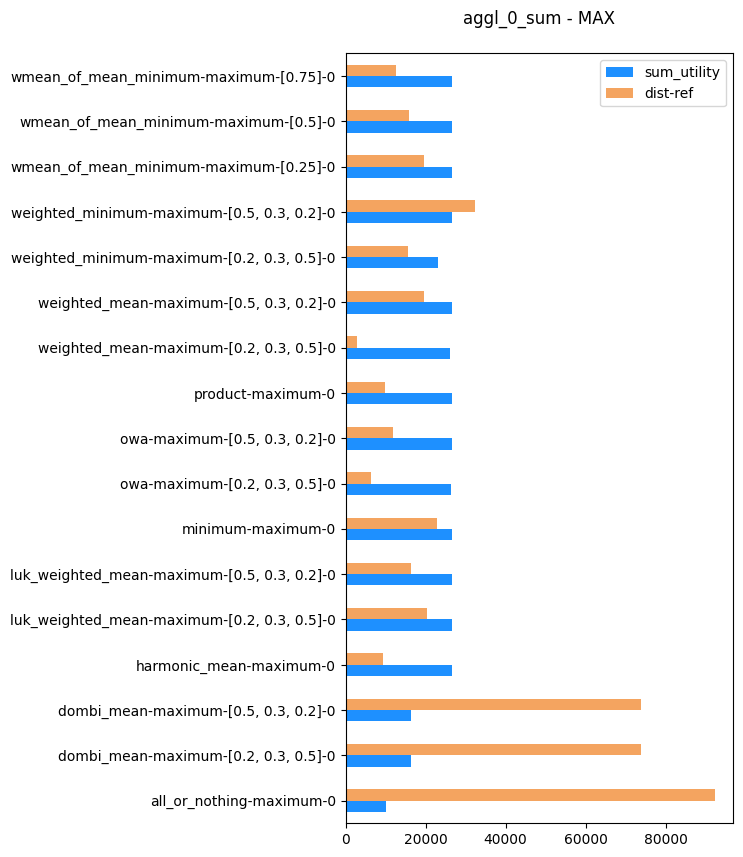

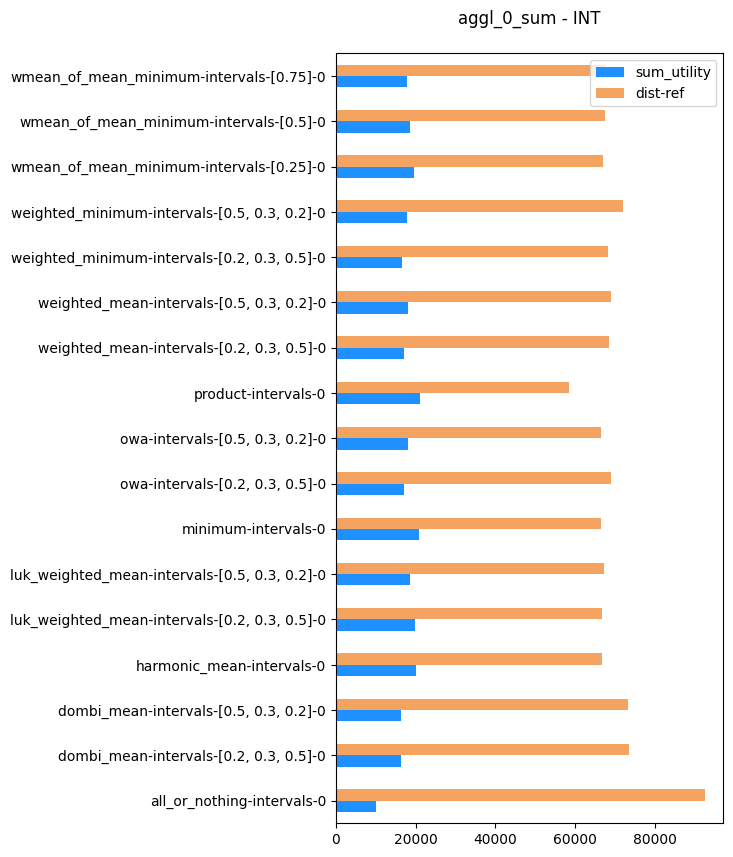

In [57]:
df_aggl_0 = df_metrics_summary[df_metrics_summary['ct_aggl'] == "0"]
df_aggl_0_max = df_aggl_0[df_aggl_0['mdec'] == "maximum"]
df_aggl_0_int = df_aggl_0[df_aggl_0['mdec'] == "intervals"]

# sum 
df_aggl_0_max_sum = df_aggl_0_max[["sum_utility", "dist-ref"]]

df_aggl_0_max_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_0_sum - MAX\n",
                      figsize=(5,10))

df_aggl_0_int_sum = df_aggl_0_int[["sum_utility", "dist-ref"]]

df_aggl_0_int_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_0_sum - INT\n",
                      figsize=(5,10))

## Ct aggl 300

<Axes: title={'center': 'aggl_300_sum - INT\n'}>

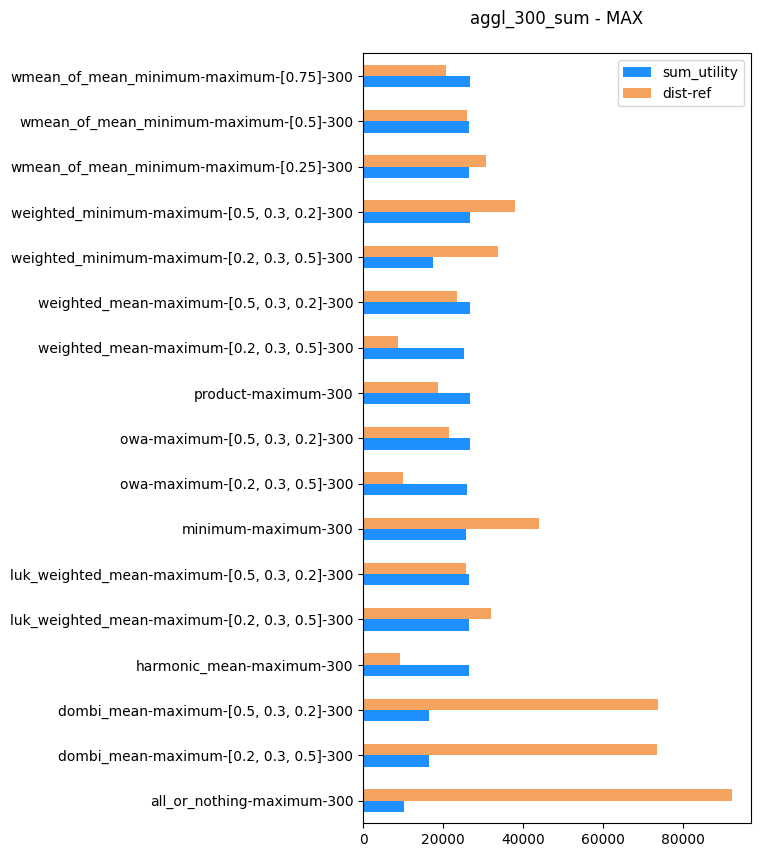

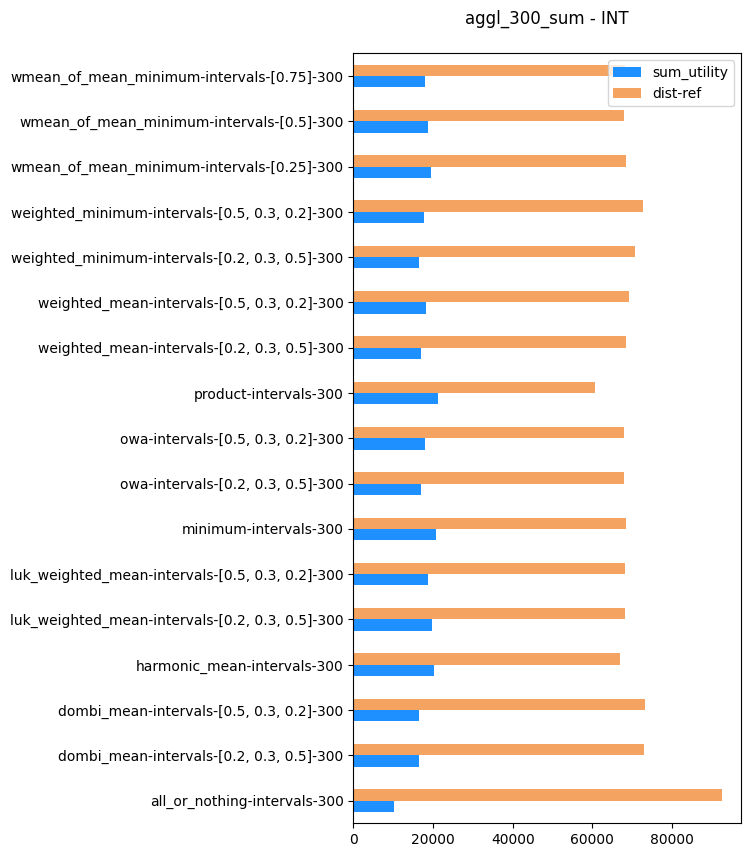

In [58]:
df_aggl_300 = df_metrics_summary[df_metrics_summary['ct_aggl'] == "300"]
df_aggl_300_max = df_aggl_300[df_aggl_300['mdec'] == "maximum"]
df_aggl_300_int = df_aggl_300[df_aggl_300['mdec'] == "intervals"]

# sum 
df_aggl_300_max_sum = df_aggl_300_max[["sum_utility", "dist-ref"]]

df_aggl_300_max_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_300_sum - MAX\n",
                      figsize=(5,10))

df_aggl_300_int_sum = df_aggl_300_int[["sum_utility", "dist-ref"]]

df_aggl_300_int_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_300_sum - INT\n",
                      figsize=(5,10))

## Ct aggl 1000

In [39]:
df_aggl_1000 = df_metrics_summary[df_metrics_summary['ct_aggl'] == "1000"]
df_aggl_1000_max = df_aggl_1000[df_aggl_1000['mdec'] == "maximum"]
df_aggl_1000_int = df_aggl_1000[df_aggl_1000['mdec'] == "intervals"]

### SUM

<Axes: title={'center': 'aggl_1000_sum - MAX\n'}>

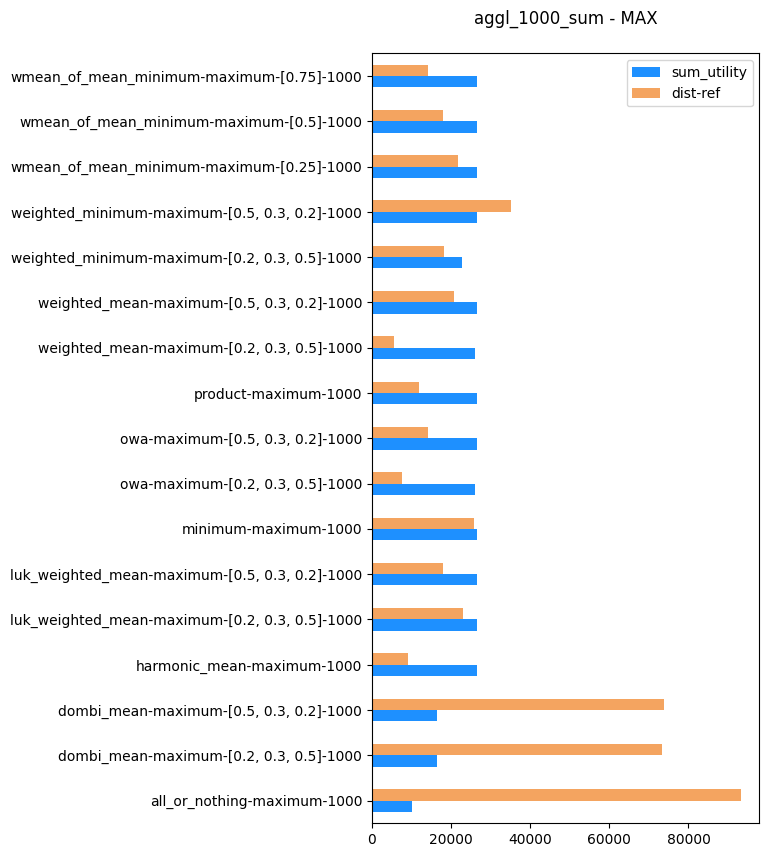

In [41]:
df_aggl_1000_max[["sum_utility", "dist-ref"]].plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_1000_sum - MAX\n",
                      figsize=(5,10))

<Axes: title={'center': 'aggl_1000_sum - INT\n'}>

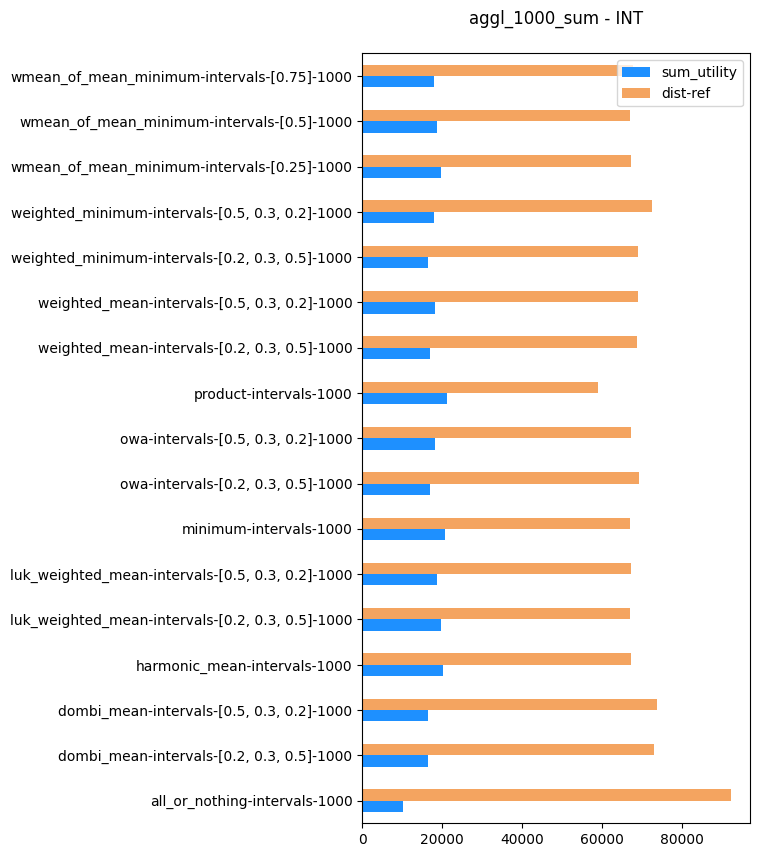

In [42]:
df_aggl_1000_int[["sum_utility", "dist-ref"]].plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_1000_sum - INT\n",
                      figsize=(5,10))

## Ct aggl 3000

<Axes: title={'center': 'aggl_3000_sum - INT\n'}>

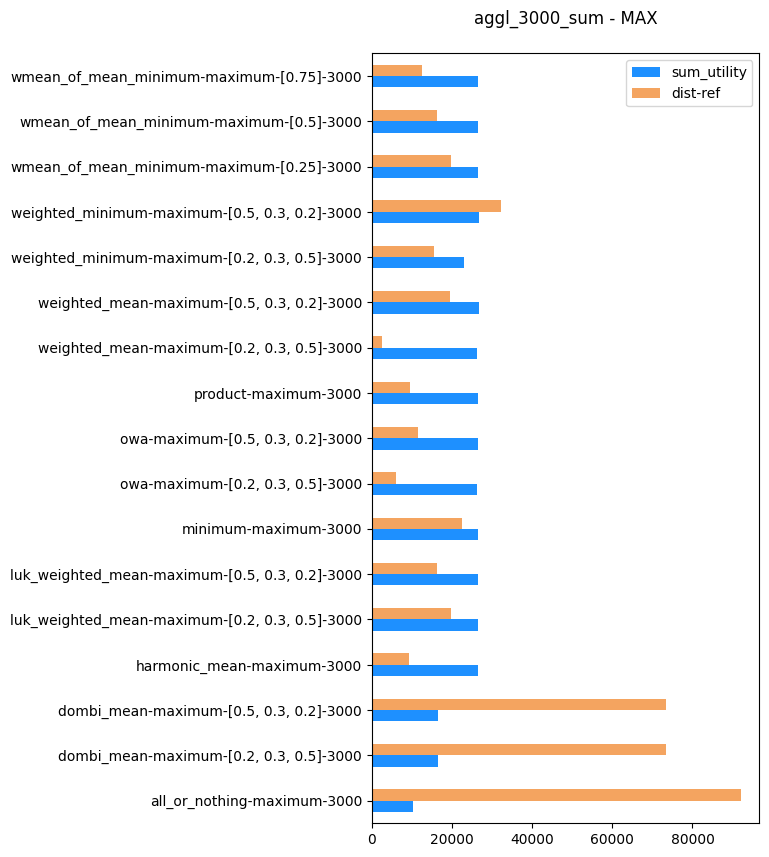

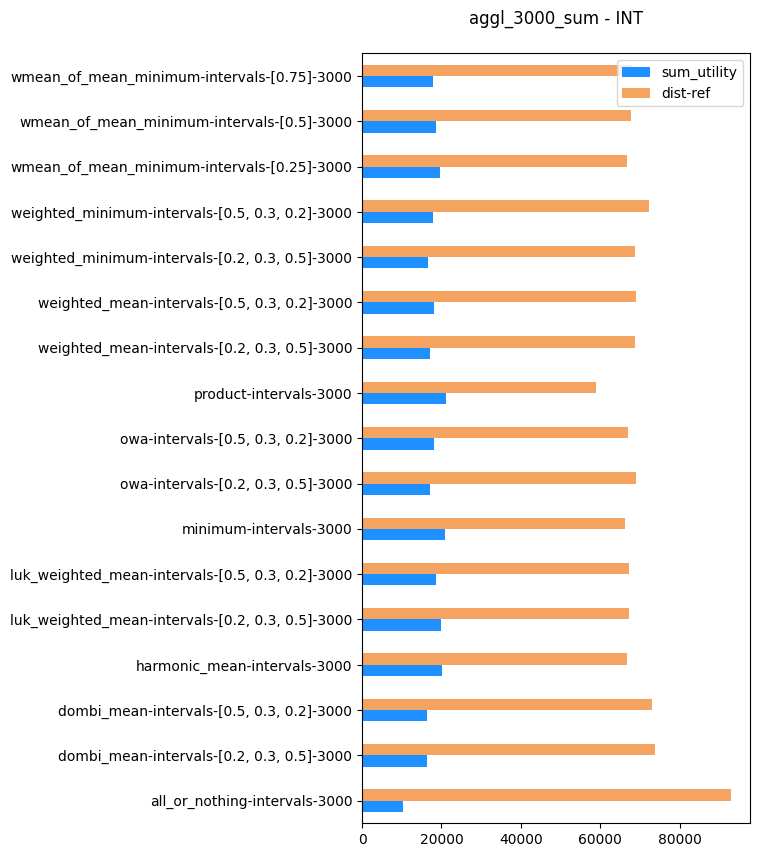

In [44]:
df_aggl_3000 = df_metrics_summary[df_metrics_summary['ct_aggl'] == "3000"]
df_aggl_3000_max = df_aggl_3000[df_aggl_3000['mdec'] == "maximum"]
df_aggl_3000_int = df_aggl_3000[df_aggl_3000['mdec'] == "intervals"]

# sum 
df_aggl_3000_max_sum = df_aggl_3000_max[["sum_utility", "dist-ref"]]

df_aggl_3000_max_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_3000_sum - MAX\n",
                      figsize=(5,10))

df_aggl_3000_int_sum = df_aggl_3000_int[["sum_utility", "dist-ref"]]

df_aggl_3000_int_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_3000_sum - INT\n",
                      figsize=(5,10))

## Ct aggl 6500

<Axes: title={'center': 'aggl_6500_sum - INT\n'}>

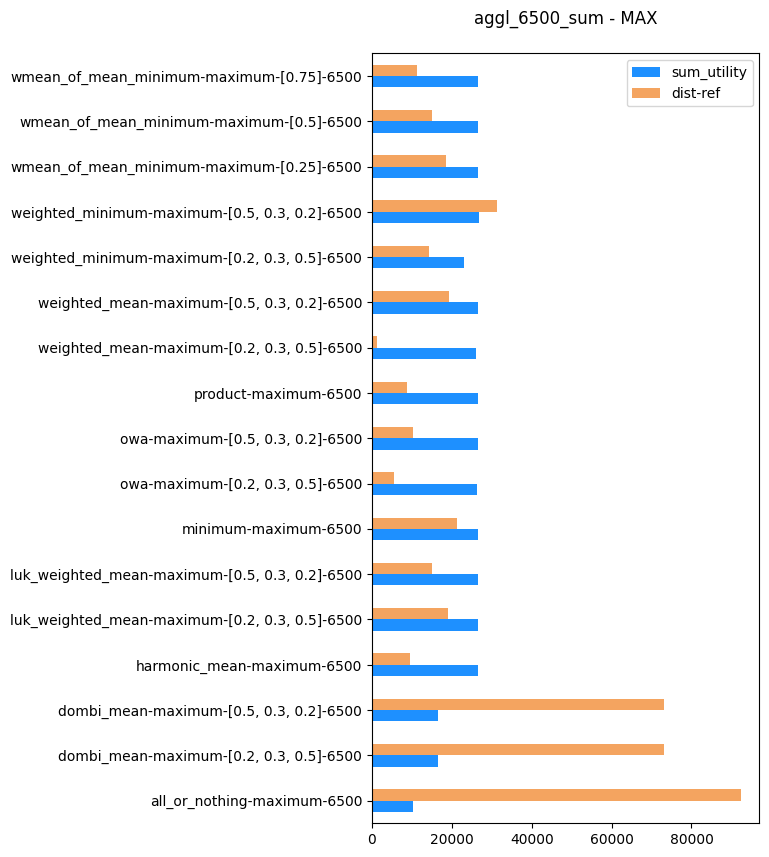

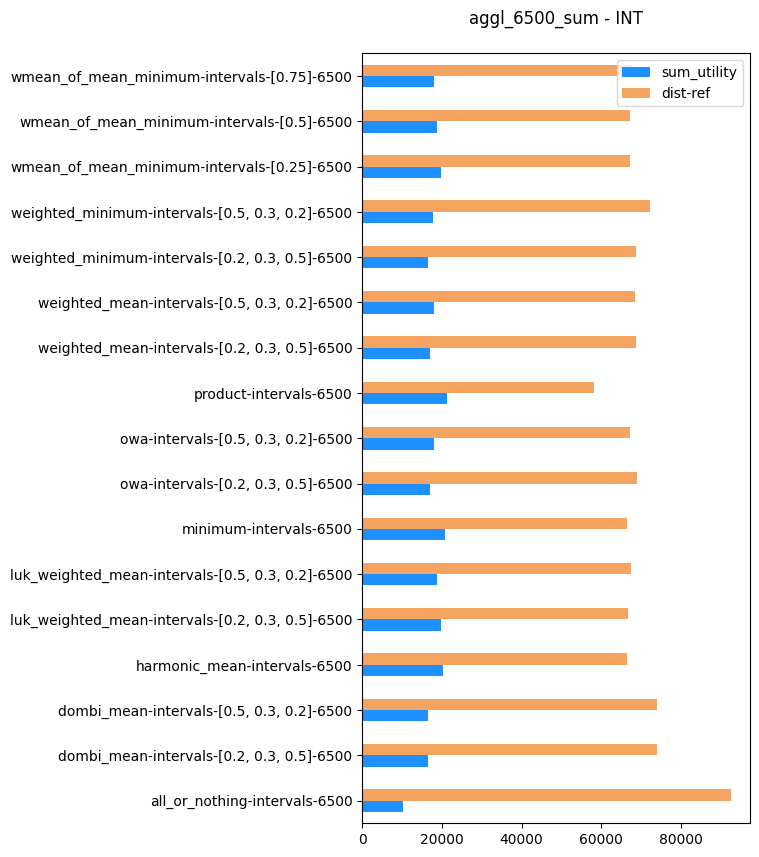

In [45]:
 
df_aggl_6500 = df_metrics_summary[df_metrics_summary['ct_aggl'] == "6500"]
df_aggl_6500_max = df_aggl_6500[df_aggl_6500['mdec'] == "maximum"]
df_aggl_6500_int = df_aggl_6500[df_aggl_6500['mdec'] == "intervals"]

# sum 
df_aggl_6500_max_sum = df_aggl_6500_max[["sum_utility", "dist-ref"]]

df_aggl_6500_max_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_6500_sum - MAX\n",
                      figsize=(5,10))

df_aggl_6500_int_sum = df_aggl_6500_int[["sum_utility", "dist-ref"]]

df_aggl_6500_int_sum.plot(kind="barh",
                      color=['dodgerblue', 'sandybrown'],
                      title="aggl_6500_sum - INT\n",
                      figsize=(5,10))

### Testing

In [ ]:
min_max = pd.read_csv(
                'test_sim/data_6500_1it/palma_poi_metrics_6500_20_minimum_maximum_noise_sigma_0.25_it-1_agg-1000.csv',
                    header=0,
                )

In [ ]:
min_max.head()

In [ ]:
min_max.columns

In [ ]:
sum_cols = ['cumulative utility', 'cumulative distance']

average_cols = ['average utility', 'average distance', 'different visited sites',
       'mass visited sites']

max_cols = ['maximum utility', 'maximum distance']

min_cols = ['minimum utility', 'minimum distance']

In [ ]:
sum_cols_results = min_max.loc[:,sum_cols].sum(axis=0)
average_cols_results = min_max.loc[:,average_cols].sum(axis=0)
max_cols_results = min_max.loc[:,max_cols].sum(axis=0)
min_cols_results = min_max.loc[:,min_cols].sum(axis=0)

In [ ]:
cols_results = [average_cols_results, max_cols_results, min_cols_results]
min_max_metrics = pd.DataFrame(data=sum_cols_results).transpose()
for col in cols_results:
        col_df = pd.DataFrame(data=col).transpose()
        min_max_metrics = pd.concat([min_max_metrics, col_df], axis=1)

In [ ]:
# reorder columns
min_max_metrics = min_max_metrics[min_max.columns]

In [ ]:
min_max_metrics.head()